In [32]:
import sys
sys.path.append("..")

from src.data_loader import load_data, split_data
from pathlib import Path
import polars as pl
from src.models.classifier import build_svm_classifier
from src.models.compensator import CORALCompensator, PCAWhiteningCompensator
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

from src.config import load_config
cfg = load_config(path=Path("../config.yaml"))

In [33]:
data = load_data(Path(f"../{cfg.paths.data_dir}"))

In [34]:
train_data, _ = split_data(data, split_after_batch=6)

X_train= train_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
y_train = train_data["label"].to_numpy()

clf = build_svm_classifier(n_components=10)
clf.fit(X_train, y_train)

baseline_f1_scores = []

for i in range(1, 11):
    eval_data = data.filter(pl.col("batch_id") == i)
    X, y = eval_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy(), eval_data["label"].to_numpy()

    y_pred = clf.predict(X)
    score = f1_score(y, y_pred, average="macro")
    baseline_f1_scores.append(score)

print(baseline_f1_scores)

[0.7155748091887563, 0.9642352321348829, 0.9711714104288383, 0.8352834467120183, 0.9854297452584507, 0.9491355702826575, 0.654306727664265, 0.4080571152529943, 0.4721552973041068, 0.4659790880130712]


In [35]:
train_data, test_data = split_data(data, split_after_batch=6)

X_train= train_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
y_train = train_data["label"].to_numpy()

coral = CORALCompensator()

coral.fit(X_train)

clf = build_svm_classifier(n_components=10)
clf.fit(X_train, y_train)

coral_f1_scores = []

for i in range(1, 11):
    eval_data = data.filter(pl.col("batch_id") == i)
    X, y = eval_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy(), eval_data["label"].to_numpy()
    if i >= 7:
        X = coral.transform(X)

    y_pred = clf.predict(X)
    score = f1_score(y, y_pred, average="macro")
    coral_f1_scores.append(score)

print(coral_f1_scores)

[0.7155748091887563, 0.9642352321348829, 0.9711714104288383, 0.8352834467120183, 0.9854297452584507, 0.9491355702826575, 0.7678007525345198, 0.3651822005100143, 0.2774614742088311, 0.5539413726442365]


In [36]:
train_data, test_data = split_data(data, split_after_batch=6)

X_train= train_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
y_train = train_data["label"].to_numpy()

X_test_all = test_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
y_test = test_data["label"].to_numpy()

pca = PCAWhiteningCompensator()

pca.fit(X_train)
X_train_whitened = pca.transform(X_train)
X_test_aligned = pca.transform(X_test_all)

clf = build_svm_classifier(n_components=10)
clf.fit(X_train_whitened, y_train)

pca_f1_scores = []

for i in range(1, 11):
    if i < 7:
        eval_data = data.filter(pl.col("batch_id") == i)
        X, y = eval_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy(), eval_data["label"].to_numpy()
        X = pca.transform(X)
    else:
        mask = test_data["batch_id"] == i
        X = X_test_aligned[mask]
        y = y_test[mask]

    y_pred = clf.predict(X)
    score = f1_score(y, y_pred, average="macro")
    pca_f1_scores.append(score)

print(pca_f1_scores)

[0.9555141235408064, 0.9892475811687585, 0.991578029018245, 0.9742993848257007, 0.9932969917221885, 0.9857820521868081, 0.8168228694755567, 0.49928442668419454, 0.6191649598907664, 0.7564250297135832]


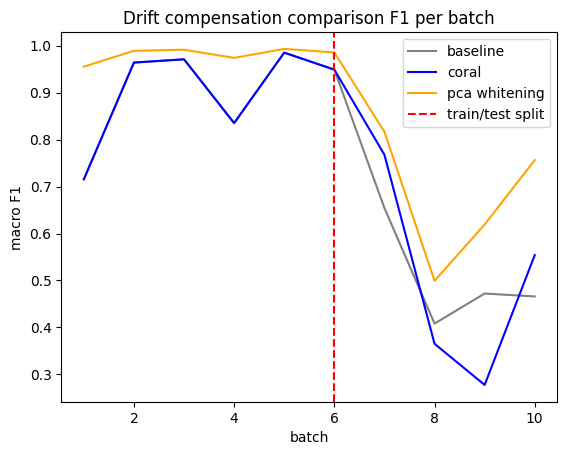

In [37]:
plt.plot(np.arange(1, 11), baseline_f1_scores, color="grey", label="baseline")
plt.plot(np.arange(1, 11), coral_f1_scores, color="blue", label="coral")
plt.plot(np.arange(1, 11), pca_f1_scores, color="orange", label="pca whitening")
plt.axvline(x=6, color="red", linestyle="--", label="train/test split")
plt.xlabel("batch")
plt.ylabel("macro F1")
plt.title("Drift compensation comparison F1 per batch")
plt.legend()
plt.savefig(f"../{cfg.paths.results_dir}/compensation_comparison.png")
plt.show()